In [1]:
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords

In [ ]:
nltk.download('stopwords')

In [2]:
df = pd.read_csv("dialect_dataset.csv")
df.head()

,text,dialect
0,"""انا رايح الشغل بدري النهارده""",egyptian
1,"""هو لسه مجاش لحد دلوقتي""",egyptian
2,"""انتي هتعملي ايه بكرة؟""",egyptian
3,"""الجو حر اوي اليومين دول""",egyptian
4,"""انا مش فاضي خالص دلوقتي""",egyptian


In [3]:
def normalize_arabic(text):
    # Remove tashkeel
    text = re.sub(r'[\u0617-\u061A\u064B-\u0652]', '', text)

    # Remove URLs
    text = re.sub(r'http\S+|www.\S+', '', text)

    # Remove emojis & non-Arabic chars
    text = re.sub(r'[^\u0600-\u06FF\s]', '', text)

    # Normalize letters
    text = re.sub(r'[إأآا]', 'ا', text)
    text = re.sub(r'ة', 'ه', text)
    text = re.sub(r'ى', 'ي', text)

    # Remove repeated letters (e.g., "حلوووو" → "حلو")
    text = re.sub(r'(.)\1+', r'\1', text)

    # Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [4]:
df["clean_text"] = df["text"].apply(normalize_arabic)
df.head()

,text,dialect,clean_text
0,"""انا رايح الشغل بدري النهارده""",egyptian,انا رايح الشغل بدري النهارده
1,"""هو لسه مجاش لحد دلوقتي""",egyptian,هو لسه مجاش لحد دلوقتي
2,"""انتي هتعملي ايه بكرة؟""",egyptian,انتي هتعملي ايه بكره؟
3,"""الجو حر اوي اليومين دول""",egyptian,الجو حر اوي اليومين دول
4,"""انا مش فاضي خالص دلوقتي""",egyptian,انا مش فاضي خالص دلوقتي


In [5]:
arabic_stopwords = set(stopwords.words("arabic"))

def remove_stopwords(text):
    tokens = text.split()
    filtered = [word for word in tokens if word not in arabic_stopwords]
    return " ".join(filtered)

In [6]:
df["clean_text"] = df["clean_text"].apply(remove_stopwords)
df.head()

,text,dialect,clean_text
0,"""انا رايح الشغل بدري النهارده""",egyptian,انا رايح الشغل بدري النهارده
1,"""هو لسه مجاش لحد دلوقتي""",egyptian,لسه مجاش لحد دلوقتي
2,"""انتي هتعملي ايه بكرة؟""",egyptian,انتي هتعملي ايه بكره؟
3,"""الجو حر اوي اليومين دول""",egyptian,الجو حر اوي اليومين دول
4,"""انا مش فاضي خالص دلوقتي""",egyptian,انا مش فاضي خالص دلوقتي


In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

X = df["clean_text"]
y = df["dialect"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

vectorizer = TfidfVectorizer(ngram_range=(1,2), max_features=3000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

LogisticReg_model = LogisticRegression(max_iter=200)
LogisticReg_model.fit(X_train_tfidf, y_train)

y_pred = LogisticReg_model.predict(X_test_tfidf)

print("LogisticRegression Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

LogisticRegression Accuracy: 0.75

Classification Report:
               precision    recall  f1-score   support

    egyptian       0.79      0.75      0.77        20
        gulf       0.65      0.75      0.70        20
   levantine       0.83      0.75      0.79        20

    accuracy                           0.75        60
   macro avg       0.76      0.75      0.75        60
weighted avg       0.76      0.75      0.75        60



In [8]:
def predict_dialect(sentence):
    clean = normalize_arabic(sentence)
    clean = remove_stopwords(clean)
    vec = vectorizer.transform([clean])
    pred = LogisticReg_model.predict(vec)[0]
    return pred

print(predict_dialect("شو عم تعمل؟"))
print(predict_dialect("انا رايح دلوقتي"))
print(predict_dialect("شلونك اليوم؟"))

levantine
egyptian
gulf


In [9]:
from sklearn.svm import LinearSVC

vectorizer = TfidfVectorizer(ngram_range=(1,2), max_features=3000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# SVM
svm_model = LinearSVC()
svm_model.fit(X_train_tfidf, y_train)
y_pred = svm_model.predict(X_test_tfidf)

print("SVM Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

SVM Accuracy: 0.75

Classification Report:
               precision    recall  f1-score   support

    egyptian       0.71      0.75      0.73        20
        gulf       0.71      0.75      0.73        20
   levantine       0.83      0.75      0.79        20

    accuracy                           0.75        60
   macro avg       0.75      0.75      0.75        60
weighted avg       0.75      0.75      0.75        60



In [10]:
def predict_dialect_svm(sentence):
    clean = normalize_arabic(sentence)
    clean = remove_stopwords(clean)
    vec = vectorizer.transform([clean])
    pred = svm_model.predict(vec)[0]
    return pred

print(predict_dialect_svm("شو عم تعمل؟"))
print(predict_dialect_svm("انا رايح دلوقتي"))
print(predict_dialect_svm("شلونك اليوم؟"))

levantine
egyptian
gulf


In [11]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier

# Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)
y_pred_nb = nb_model.predict(X_test_tfidf)
print("Naive Bayes Accuracy:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

# Random Forest
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train_tfidf, y_train)
y_pred_rf = rf_model.predict(X_test_tfidf)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Naive Bayes Accuracy: 0.75
              precision    recall  f1-score   support

    egyptian       0.79      0.75      0.77        20
        gulf       0.62      0.75      0.68        20
   levantine       0.88      0.75      0.81        20

    accuracy                           0.75        60
   macro avg       0.77      0.75      0.75        60
weighted avg       0.77      0.75      0.75        60

Random Forest Accuracy: 0.7
              precision    recall  f1-score   support

    egyptian       0.90      0.45      0.60        20
        gulf       0.53      0.95      0.68        20
   levantine       1.00      0.70      0.82        20

    accuracy                           0.70        60
   macro avg       0.81      0.70      0.70        60
weighted avg       0.81      0.70      0.70        60



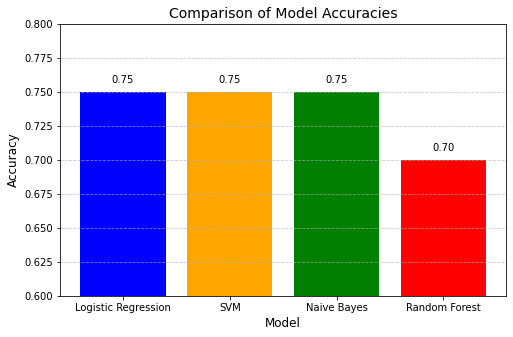

In [12]:
import matplotlib.pyplot as plt

# أسماء النماذج
models = ['Logistic Regression', 'SVM', 'Naive Bayes', 'Random Forest']

# نسب الدقة لكل نموذج
accuracies = [0.75, 0.75, 0.75, 0.70]

# إنشاء الرسم البياني
plt.figure(figsize=(8, 5))
bars = plt.bar(models, accuracies, color=['blue', 'orange', 'green', 'red'])

# إضافة عنوان ومحاور
plt.title('Comparison of Model Accuracies', fontsize=14)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.ylim(0.6, 0.8)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# إضافة القيم فوق الأعمدة
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, acc + 0.005, f'{acc:.2f}', 
             ha='center', va='bottom', fontsize=10)

# عرض الرسم
plt.show()

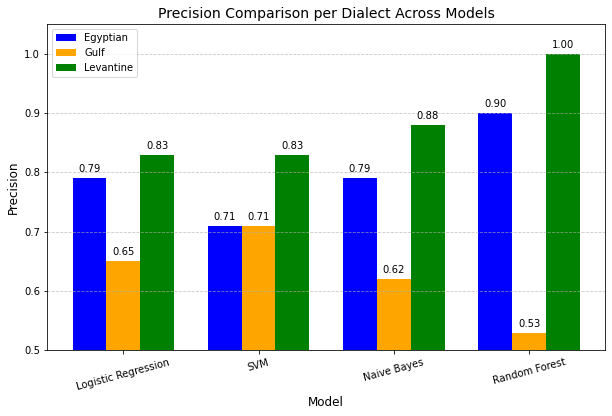

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# أسماء النماذج
models = ['Logistic Regression', 'SVM', 'Naive Bayes', 'Random Forest']

# قيم precision لكل لهجة داخل كل نموذج
egyptian_precision = [0.79, 0.71, 0.79, 0.90]
gulf_precision      = [0.65, 0.71, 0.62, 0.53]
levantine_precision = [0.83, 0.83, 0.88, 1.00]

# تحديد مواقع الأعمدة
x = np.arange(len(models))
width = 0.25

# إنشاء الرسم البياني
plt.figure(figsize=(10, 6))
plt.bar(x - width, egyptian_precision, width, label='Egyptian', color='blue')
plt.bar(x, gulf_precision, width, label='Gulf', color='orange')
plt.bar(x + width, levantine_precision, width, label='Levantine', color='green')

# إعدادات الشكل
plt.title('Precision Comparison per Dialect Across Models', fontsize=14)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.xticks(x, models, rotation=15)
plt.ylim(0.5, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()

# عرض القيم فوق الأعمدة
for i in range(len(models)):
    plt.text(x[i] - width, egyptian_precision[i] + 0.01, f'{egyptian_precision[i]:.2f}', ha='center')
    plt.text(x[i], gulf_precision[i] + 0.01, f'{gulf_precision[i]:.2f}', ha='center')
    plt.text(x[i] + width, levantine_precision[i] + 0.01, f'{levantine_precision[i]:.2f}', ha='center')

# عرض الرسم
plt.show()

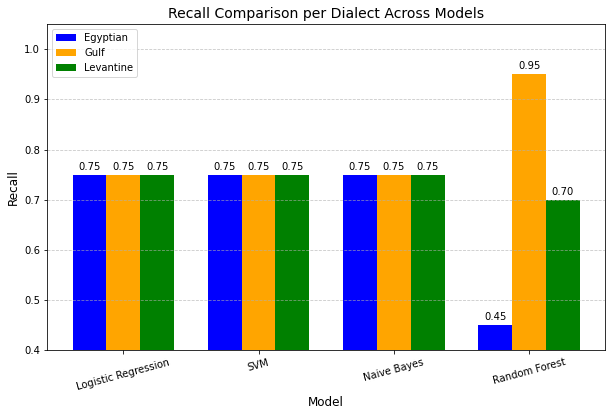

In [14]:
import matplotlib.pyplot as plt
import numpy as np

# أسماء النماذج
models = ['Logistic Regression', 'SVM', 'Naive Bayes', 'Random Forest']

# قيم recall لكل لهجة داخل كل نموذج (من تقاريرك السابقة)
egyptian_recall = [0.75, 0.75, 0.75, 0.45]
gulf_recall      = [0.75, 0.75, 0.75, 0.95]
levantine_recall = [0.75, 0.75, 0.75, 0.70]

# تحديد مواقع الأعمدة
x = np.arange(len(models))
width = 0.25

# إنشاء الرسم البياني
plt.figure(figsize=(10, 6))
plt.bar(x - width, egyptian_recall, width, label='Egyptian', color='blue')
plt.bar(x, gulf_recall, width, label='Gulf', color='orange')
plt.bar(x + width, levantine_recall, width, label='Levantine', color='green')

# إعدادات الشكل
plt.title('Recall Comparison per Dialect Across Models', fontsize=14)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Recall', fontsize=12)
plt.xticks(x, models, rotation=15)
plt.ylim(0.4, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()

# عرض القيم فوق الأعمدة
for i in range(len(models)):
    plt.text(x[i] - width, egyptian_recall[i] + 0.01, f'{egyptian_recall[i]:.2f}', ha='center')
    plt.text(x[i], gulf_recall[i] + 0.01, f'{gulf_recall[i]:.2f}', ha='center')
    plt.text(x[i] + width, levantine_recall[i] + 0.01, f'{levantine_recall[i]:.2f}', ha='center')

# عرض الرسم
plt.show()

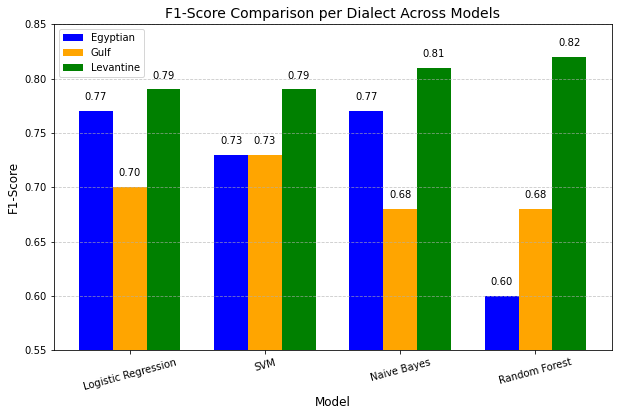

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# أسماء النماذج
models = ['Logistic Regression', 'SVM', 'Naive Bayes', 'Random Forest']

# قيم f1-score لكل لهجة داخل كل نموذج (من تقاريرك السابقة)
egyptian_f1 = [0.77, 0.73, 0.77, 0.60]
gulf_f1      = [0.70, 0.73, 0.68, 0.68]
levantine_f1 = [0.79, 0.79, 0.81, 0.82]

# تحديد مواقع الأعمدة
x = np.arange(len(models))
width = 0.25

# إنشاء الرسم البياني
plt.figure(figsize=(10, 6))
plt.bar(x - width, egyptian_f1, width, label='Egyptian', color='blue')
plt.bar(x, gulf_f1, width, label='Gulf', color='orange')
plt.bar(x + width, levantine_f1, width, label='Levantine', color='green')

# إعدادات الشكل
plt.title('F1-Score Comparison per Dialect Across Models', fontsize=14)
plt.xlabel('Model', fontsize=12)
plt.ylabel('F1-Score', fontsize=12)
plt.xticks(x, models, rotation=15)
plt.ylim(0.55, 0.85)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()

# عرض القيم فوق الأعمدة
for i in range(len(models)):
    plt.text(x[i] - width, egyptian_f1[i] + 0.01, f'{egyptian_f1[i]:.2f}', ha='center')
    plt.text(x[i], gulf_f1[i] + 0.01, f'{gulf_f1[i]:.2f}', ha='center')
    plt.text(x[i] + width, levantine_f1[i] + 0.01, f'{levantine_f1[i]:.2f}', ha='center')

# عرض الرسم
plt.show()

In [16]:
import pandas as pd
import re
from difflib import get_close_matches

# تحميل القاموس من ملف CSV
df_dict = pd.read_csv("dictionary.csv", encoding="utf-8")
dialect_to_msa = dict(zip(df_dict["word"], df_dict["msa"]))

# دالة لتحديد إذا الكلمة مؤنثة
def is_feminine(word):
    return word.endswith("ة")

# دالة لضبط التذكير والتأنيث للصفة
def adjust_gender(noun, adjective):
    if is_feminine(noun):
        if not adjective.endswith("ة"):
            return adjective + "ة"
    return adjective

# دالة لتحديد إذا الكلمة أداة ربط
def is_particle(word):
    particles = {"لكن", "ثم", "بل", "و", "او"}
    return word in particles

# دالة لتحديد إذا الكلمة اسم (قاعدة عامة: تبدأ بـ "ال")
def is_noun(word):
    return word.startswith("ال")

def normalize_to_msa(text):
    # استبدال العبارات داخل النص بالقاموس
    for phrase, msa_phrase in dialect_to_msa.items(): # Substring match
        text = re.sub(rf'\b{re.escape(phrase)}\b', msa_phrase, text)

    # تقسيم النص إلى كلمات + رموز
    tokens = re.findall(r'\w+|\s+|[^\w\s]', text)

    normalized_tokens = []
    for token in tokens: # Tokens match
        word = token.strip()
        if word in dialect_to_msa:
            normalized_tokens.append(dialect_to_msa[word])
        else:
            close = get_close_matches(word, dialect_to_msa.keys(), n=1, cutoff=0.7)
            if close:
                normalized_tokens.append(dialect_to_msa[close[0]])
            else:
                normalized_tokens.append(token)

    normalized_text = "".join(normalized_tokens)

    # ضبط التذكير والتأنيث للصفات مع مراعاة الأدوات والأسماء
    words = normalized_text.split()
    adjusted_words = []
    for i in range(len(words)):
        if i > 0:
            noun = words[i-1]
            current = words[i]
            # إذا الكلمة أداة أو اسم (مبدوءة بال التعريف) → لا نؤنثها
            if is_particle(current) or is_noun(current):
                adjusted_words.append(current)
                continue
            # إذا صفة → نعدلها حسب جنس الاسم السابق
            current = adjust_gender(noun, current)
            adjusted_words.append(current)
        else:
            adjusted_words.append(words[i])

    return " ".join(adjusted_words)

In [17]:
print(normalize_to_msa("شو عم تعمل هلأ؟"))
print(normalize_to_msa("وااايد حلو الجو الحين!"))
print(normalize_to_msa("انا راااايح دلوقتي."))
print(normalize_to_msa("انا هعدي عليك بعد شوية"))
print(normalize_to_msa("هوني الجو بردان"))
print(normalize_to_msa("هي راحت فين؟"))
print(normalize_to_msa("انا جعااان وعايز اكل"))
print(normalize_to_msa("انتي هتعملي ايه بكرة؟"))
print(normalize_to_msa("انا مش فاهم انت قصدك ايه"))
print(normalize_to_msa("الولد ده شاطر اوي"))
print(normalize_to_msa("القهوة زينة بس غالية"))
print(normalize_to_msa("الحين بروح أشتري أغراض من السوق"))

ماذا سوف تفعل الآن؟
كثير جميل الطقس الآن!
انا ذاهب الآن.
انا سآتي عليك بعد قليل
هنا الطقس بارد
هذه ذهبت أين؟
انا جائع أريد طعام
أنتِ تفعل ماذا غدًا؟
انا ليس فاهم أنت ماذا تقصد
الفتى هذا ذكي جداً
قهوة زينة لكن مرتفعة الثمن
الآن أذهب أشتري أغراض من سوق


In [18]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report
import joblib

# تحميل البيانات
df = pd.read_csv("dialect_dataset.csv")

# تقسيم النصوص والتصنيفات
X = df["text"]
y = df["dialect"]

# تقسيم البيانات إلى تدريب واختبار
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# تحويل النصوص إلى ميزات TF‑IDF
vectorizer = TfidfVectorizer(max_features=2000, ngram_range=(1,2))
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

# تدريب نموذج SVM خفيف
dialect_model = LinearSVC()
dialect_model.fit(X_train_vec, y_train)

# حفظ النموذج والمتجهات
joblib.dump(dialect_model, "dialect_svm.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

print("✅ تم تدريب النموذج وحفظ الملفات بنجاح!")

✅ تم تدريب النموذج وحفظ الملفات بنجاح!


In [19]:
import ipywidgets as widgets
from IPython.display import display, HTML

# مربع إدخال النص باللهجة
text_input = widgets.Textarea(
    value='',
    placeholder='اكتب النص باللهجة هنا...',
    description='النص:',
    layout=widgets.Layout(width='90%', height='120px')
)

# زر التحليل
analyze_button = widgets.Button(
    description="🔍 تحليل النص",
    button_style='info',
    layout=widgets.Layout(width='30%', height='40px')
)

# منطقة عرض النتائج
dialect_output = widgets.HTML(value="<b>اللهجة المكتشفة:</b> -")
normalized_output = widgets.HTML(value="<b>النص بالفصحى:</b> -")

# صندوق النتائج مع تنسيق
results_box = widgets.VBox([
    widgets.HTML("<h3 style='color:#2c3e50;'>📊 النتائج</h3>"),
    dialect_output,
    normalized_output
])

# دالة المعالجة
def process_text(b):
    user_text = text_input.value.strip()
    if not user_text:
        dialect_output.value = "<b style='color:red;'>⚠️ الرجاء إدخال نص باللهجة</b>"
        normalized_output.value = ""
        return
    
    # استخدام النموذج والدوال الموجودة عندك
    features = vectorizer.transform([user_text])
    dialect = dialect_model.predict(features)[0]
    normalized = normalize_to_msa(user_text)
    
    dialect_output.value = f"<b>اللهجة المكتشفة:</b> <span style='color:blue;'>{dialect}</span>"
    normalized_output.value = f"<b>النص بالفصحى:</b> <span style='color:green;'>{normalized}</span>"

# ربط الزر بالدالة
analyze_button.on_click(process_text)

# عرض الواجهة
ui = widgets.VBox([
    widgets.HTML("<h2 style='color:#34495e;'>📝 نظام كشف اللهجة وتطبيع النص</h2>"),
    text_input,
    analyze_button,
    results_box
])

display(ui)

In [20]:
# تقييم النموذج
y_pred = dialect_model.predict(X_test_vec)

print("✅ Accuracy:", accuracy_score(y_test, y_pred))
print("✅ F1-score (macro):", f1_score(y_test, y_pred, average="macro"))
print("\n📊 Classification Report:\n", classification_report(y_test, y_pred))

✅ Accuracy: 0.65
✅ F1-score (macro): 0.6483516483516484

📊 Classification Report:
               precision    recall  f1-score   support

    egyptian       0.83      0.62      0.71        24
        gulf       0.48      0.56      0.51        18
   levantine       0.67      0.78      0.72        18

    accuracy                           0.65        60
   macro avg       0.66      0.65      0.65        60
weighted avg       0.68      0.65      0.65        60

